In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_curve, auc, confusion_matrix, classification_report
)
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/creditcard.csv")
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

final_model = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight
)
final_model.fit(X_train, y_train)

# Get probabilities, not just hard predictions
y_probs = final_model.predict_proba(X_test)[:, 1]

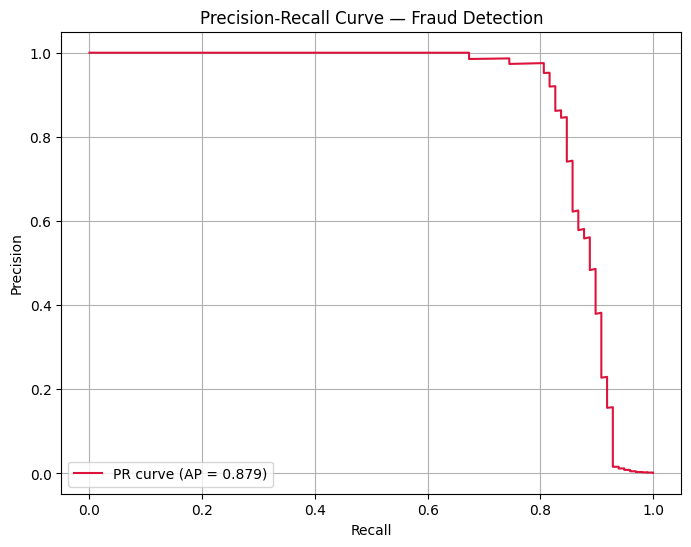

Average Precision (PR-AUC): 0.8790551796218564


In [2]:
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
avg_precision = average_precision_score(y_test, y_probs)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'PR curve (AP = {avg_precision:.3f})', color='crimson')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Fraud Detection')
plt.legend()
plt.grid(True)
plt.savefig('../assets/precision_recall_curve.png')
plt.show()

print("Average Precision (PR-AUC):", avg_precision)

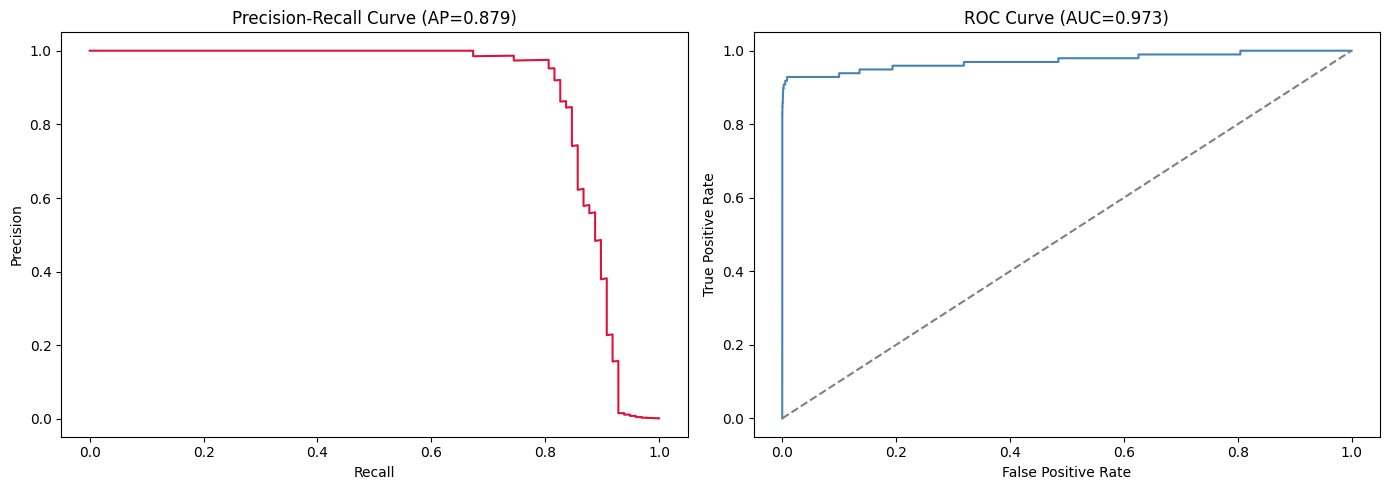

In [3]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(recall, precision, color='crimson')
axes[0].set_title(f'Precision-Recall Curve (AP={avg_precision:.3f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')

axes[1].plot(fpr, tpr, color='steelblue')
axes[1].plot([0,1],[0,1], linestyle='--', color='gray')
axes[1].set_title(f'ROC Curve (AUC={roc_auc:.3f})')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')

plt.tight_layout()
plt.savefig('../assets/pr_vs_roc.png')
plt.show()

In [4]:
# Example: what threshold gets us 90% recall, and what's the precision cost?
target_recall = 0.90

# thresholds array is 1 shorter than precision/recall arrays
idx = np.argmin(np.abs(recall[:-1] - target_recall))
best_threshold = thresholds[idx]

print(f"To achieve ~{target_recall*100:.0f}% recall:")
print(f"Threshold: {best_threshold:.4f}")
print(f"Precision at this threshold: {precision[idx]:.4f}")
print(f"Recall at this threshold: {recall[idx]:.4f}")

To achieve ~90% recall:
Threshold: 0.0033
Precision at this threshold: 0.3793
Recall at this threshold: 0.8980


In [5]:
y_pred_custom = (y_probs >= best_threshold).astype(int)

print(f"--- Model at threshold={best_threshold:.4f} (targeting {target_recall*100:.0f}% recall) ---")
print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

--- Model at threshold=0.0033 (targeting 90% recall) ---
[[56720   144]
 [   10    88]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.38      0.90      0.53        98

    accuracy                           1.00     56962
   macro avg       0.69      0.95      0.77     56962
weighted avg       1.00      1.00      1.00     56962



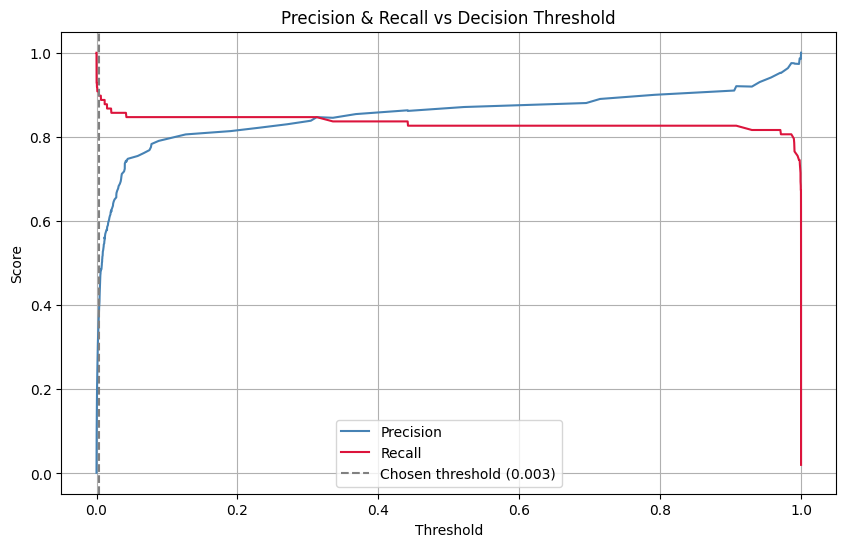

In [6]:
plt.figure(figsize=(10,6))
plt.plot(thresholds, precision[:-1], label='Precision', color='steelblue')
plt.plot(thresholds, recall[:-1], label='Recall', color='crimson')
plt.axvline(best_threshold, linestyle='--', color='gray', label=f'Chosen threshold ({best_threshold:.3f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision & Recall vs Decision Threshold')
plt.legend()
plt.grid(True)
plt.savefig('../assets/threshold_tradeoff.png')
plt.show()